In [9]:
from math import sqrt, pi
import numpy as np
import matplotlib.pyplot as plt
import torchaudio
import torch
import scipy

In [10]:
def draw_oscillogram(signal, main): #Рисование осциллограммы сигнала
    plt.plot(signal)
    plt.xlabel('Сэмпл')
    plt.ylabel('Колебания')
    plt.title(main)
    plt.grid()
    plt.show()

def draw_spectogram(signal, sample_rate, main): #Рисование спектрограммы сигнала
    plt.specgram(signal, NFFT=1024, Fs=sample_rate, noverlap=900)
    plt.xlabel('Время, с')
    plt.ylabel('Частота, Гц')
    plt.title(main)
    plt.show()

def draw_amplitude_vs_frequency(signal, sample_rate): #Рисование АЧХ сигнала
    Xf_mag = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(Xf_mag), d=1.0/sample_rate)
    plt.plot(np.abs(freqs), np.abs(Xf_mag))
    plt.title('Амплитудно-частотная характеристика')
    plt.xlabel('Частота, Гц')
    plt.ylabel('Амплитуда, Дб')
    plt.grid()
    plt.show()

def highpass_filter(signal, sample_rate, cutoff_freq=1000): #Фильтр верхних частот
    order = 5 
    b, a = scipy.signal.butter(order, cutoff_freq / (sample_rate / 2), btype='highpass', analog=False)
    filtered_waveform = scipy.signal.filtfilt(b, a, signal)
    return filtered_waveform

def butterwart_filter(signal, sample_rate, order, cutoff_freq, type='lowpass'): #Фильтр Баттерворта
    b, a = scipy.signal.butter(order, cutoff_freq / (sample_rate / 2), btype=type, analog=False)
    filtered_waveform = scipy.signal.filtfilt(b, a, signal)
    return filtered_waveform

In [13]:
import librosa
audio_file = "data/00001.wav"
signal, sr = signal, sample_rate = torchaudio.load(audio_file)
signal.shape    

torch.Size([1, 133761])

In [12]:
signal = signal.numpy().squeeze(axis=0) #Преобразование в numpy-массив

In [4]:
signal

array([-0.00448608, -0.00418091, -0.00262451, ...,  0.01773071,
        0.04971313,  0.06173706], dtype=float32)

In [5]:
print(f"Длительность сигнала: {signal.shape[0]/sr}с")

Длительность сигнала: 8.3600625с


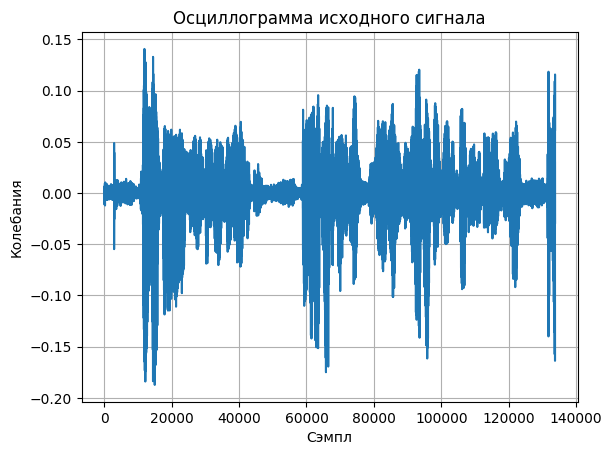

In [6]:
draw_oscillogram(signal, 'Осциллограмма исходного сигнала')

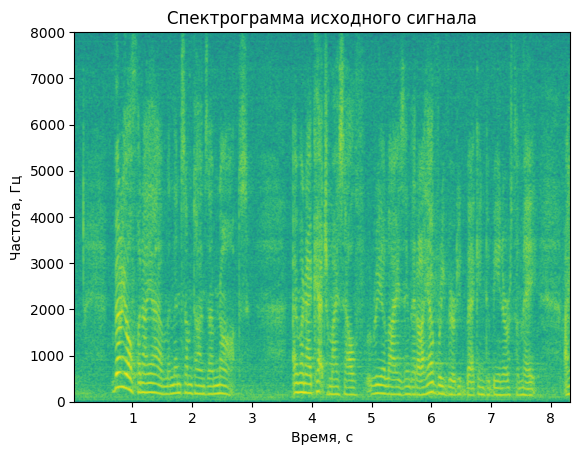

In [7]:
draw_spectogram(signal, sample_rate, 'Спектрограмма исходного сигнала')

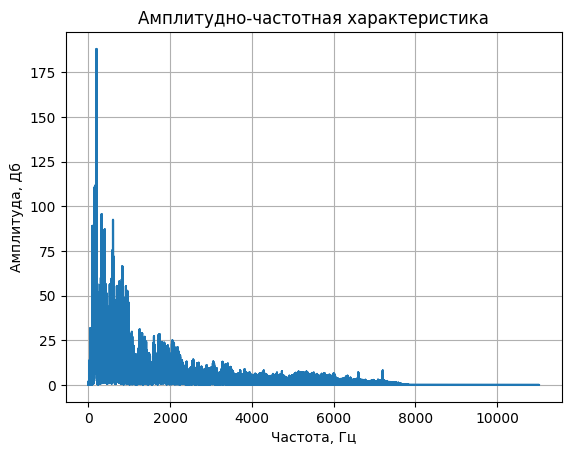

In [19]:
draw_amplitude_vs_frequency(signal, sr)

In [15]:
filtered_waveform = highpass_filter(signal, sample_rate, cutoff_freq=1000)

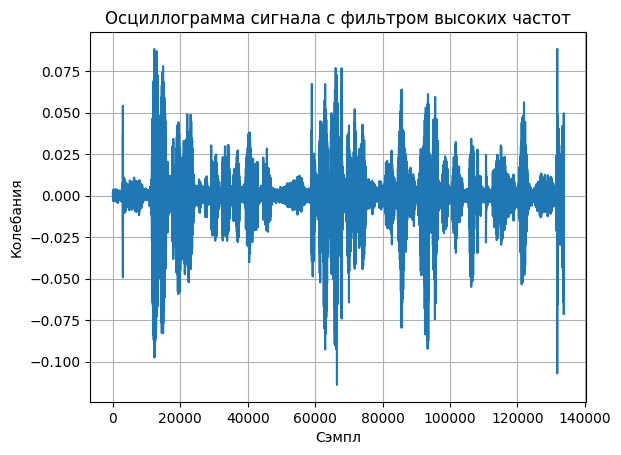

In [17]:
draw_oscillogram(filtered_waveform, 'Осциллограмма сигнала с фильтром высоких частот')

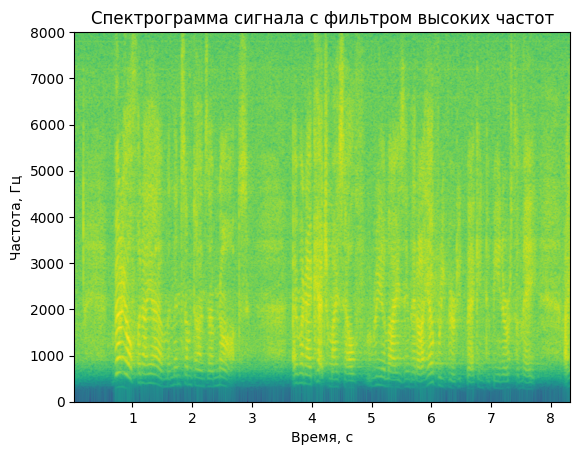

In [19]:
draw_spectogram(filtered_waveform, sample_rate, 'Спектрограмма сигнала с фильтром высоких частот')

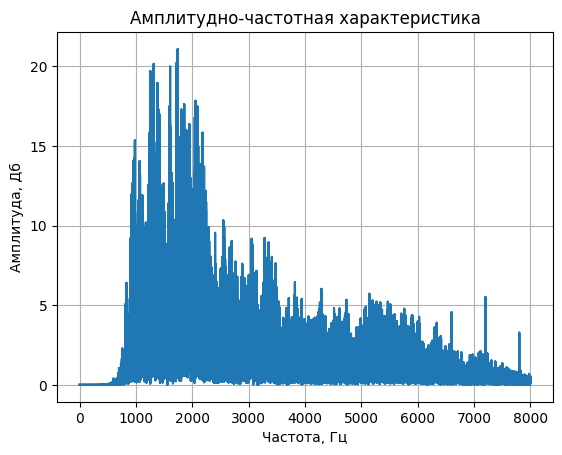

In [21]:
draw_amplitude_vs_frequency(filtered_waveform, sample_rate)

In [23]:
fw=torch.from_numpy(filtered_waveform.copy())#Преобразование обратно в тензор
torchaudio.save('filtered_01.wav', fw.type(torch.FloatTensor).reshape(1,-1), sample_rate) #Сохранение в файл

In [25]:
filtered_waveform_2 = butterwart_filter(signal, sample_rate, 3, 500, type='lowpass')

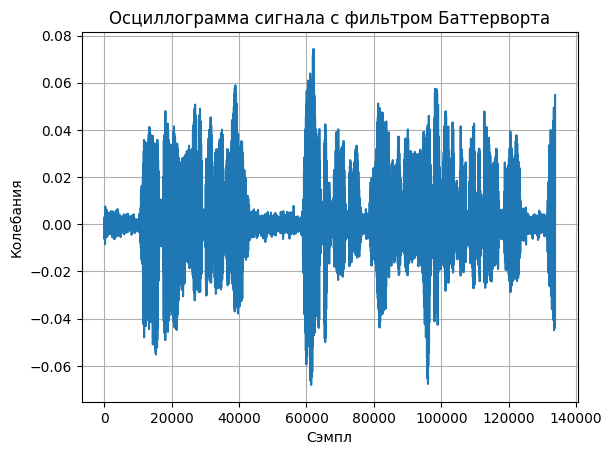

In [27]:
draw_oscillogram(filtered_waveform_2, 'Осциллограмма сигнала с фильтром Баттерворта')

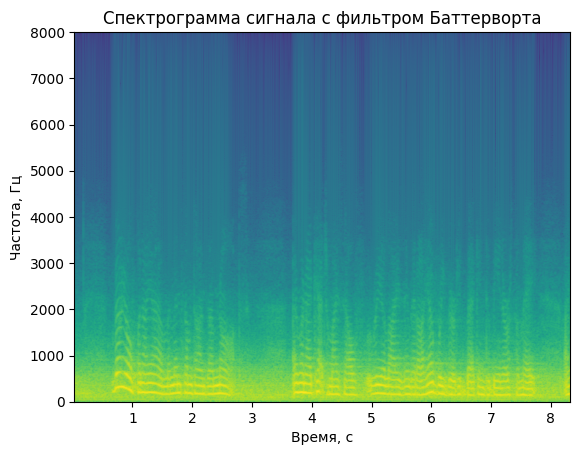

In [29]:
draw_spectogram(filtered_waveform_2, sample_rate, 'Спектрограмма сигнала с фильтром Баттерворта')

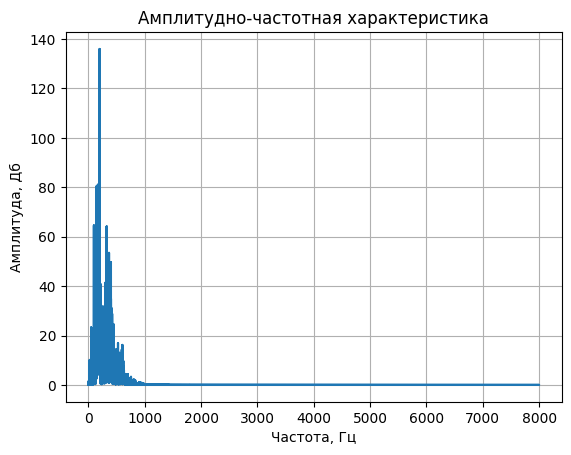

In [31]:
draw_amplitude_vs_frequency(filtered_waveform_2, sample_rate)

In [33]:
fw2=torch.from_numpy(filtered_waveform_2.copy())#Преобразование обратно в тензор
torchaudio.save('filtered_02.wav', fw2.type(torch.FloatTensor).reshape(1,-1), sample_rate) #Сохранение в файл